#### Task 1: Delivery Fee Array Calculator (NumPy)
**Build a NumPy-based program that computes and analyses delivery fees for a batch of foodorders using vectorised operations — no Python loops.**

In [1]:
''' Generate a 1D NumPy array of 25 random delivery distances between 1.0 km and 15.0 km using
np.random.uniform() with a fixed seed of 42. '''

import numpy as np

np.random.seed(42)

# Generate 25 random distances between 1.0 km and 15.0 km
distances = np.random.uniform(1.0, 15.0, 25)
print("Delivery Distances:\n", distances)

Delivery Distances:
 [ 6.24356166 14.31000029 11.24791519  9.38121878  3.18426097  3.18392328
  1.81317057 13.12646604  9.41561016 10.91301609  1.28818292 14.57873793
 12.65419697  3.97274755  3.54554954  3.56766314  5.2593914   8.34659004
  7.04723026  5.07720796  9.56594053  2.95291405  5.09002508  6.12906581
  7.38497978]


In [2]:
''' Compute the delivery fee for every order using the formula: fee = Rs 20 + Rs 5 × distance —
applied as a single vectorised expression, not a loop. '''

fees = 20 + 5 * distances
print("Delivery Fees:\n", fees)


''' Use boolean indexing to extract and print all orders where the delivery fee exceeds Rs 60,
showing both the distance and the fee for each qualifying order. '''

high_fee_mask = fees > 60
print("\nOrders with Fee > Rs 60:")
print("Distance\tFee")

# zip() pairs elements from two arrays together so we can loop over them in parallel
# Here, it pairs each qualifying distance with its corresponding fee
for d, f in zip(distances[high_fee_mask], fees[high_fee_mask]):
    print(f"{d:.2f}\t\t{f:.2f}")


Delivery Fees:
 [51.21780832 91.55000145 76.23957593 66.90609389 35.92130483 35.91961642
 29.06585285 85.6323302  67.07805082 74.56508045 26.4409146  92.89368965
 83.27098486 39.86373775 37.7277477  37.83831569 46.29695701 61.73295021
 55.2361513  45.38603981 67.82970263 34.76457025 45.4501254  50.64532903
 56.9248989 ]

Orders with Fee > Rs 60:
Distance	Fee
14.31		91.55
11.25		76.24
9.38		66.91
13.13		85.63
9.42		67.08
10.91		74.57
14.58		92.89
12.65		83.27
8.35		61.73
9.57		67.83


In [3]:
''' Print the minimum, maximum, mean, and standard deviation of the complete fee array using
NumPy statistical functions. '''

print("Minimum Fee:", np.min(fees))
print("Maximum Fee:", np.max(fees))
print("Mean Fee:", np.mean(fees))
print("Standard Deviation:", np.std(fees))


Minimum Fee: 26.440914600706172
Maximum Fee: 92.8936896513396
Mean Fee: 55.85591319825301
Standard Deviation: 19.56188200330544


#### Task 2: Restaurant Performance Analyser (Pandas)
**Build a Pandas program that creates a food delivery dataset and produces a filtered, ranked
summary of restaurant performance using groupby aggregation.**

In [4]:
''' Construct a DataFrame with at least 40 rows containing columns: restaurant_name (5 unique names), 
city (3 unique cities), order_value, delivery_time_mins, rating (1.0 - 5.0), and cuisine_type (3 types). '''

import pandas as pd
import numpy as np

# Fixed seed for reproducibility
np.random.seed(42)

# Sample categories
restaurants = ["SpiceHub", "TandooriTadaka", "UrbanFeats", "CurryChawal", "FistyFusion"]
cities = ["Delhi", "Mumbai", "Bangalore"]
cuisines = ["Indian", "Chinese", "Italian"]

# Create DataFrame with 40 rows
df = pd.DataFrame({
    "restaurant_name": np.random.choice(restaurants, 40),
    "city": np.random.choice(cities, 40),
    "order_value": np.random.uniform(100, 1000, 40),       # Rs 100–1000
    "delivery_time_mins": np.random.uniform(20, 60, 40),   # 20–60 minutes
    "rating": np.random.uniform(1.0, 5.0, 40),             # Ratings 1–5
    "cuisine_type": np.random.choice(cuisines, 40)
})

print(df.head())

  restaurant_name    city  order_value  delivery_time_mins    rating  \
0     CurryChawal   Delhi   845.863758           32.574239  2.988994   
1     FistyFusion  Mumbai   421.077994           40.342828  2.203513   
2      UrbanFeats  Mumbai   352.841059           56.302659  2.139362   
3     FistyFusion  Mumbai   588.426475           29.971689  1.147548   
4     FistyFusion   Delhi   226.831802           36.415317  3.438257   

  cuisine_type  
0      Italian  
1      Italian  
2      Chinese  
3      Chinese  
4      Italian  


In [5]:
''' Use groupby() and agg() in a single method chain to compute: mean order value, mean
delivery time, and mean rating — grouped by restaurant_name. '''

result = (
    df.groupby("restaurant_name")
      .agg(
          mean_order_value=("order_value", "mean"),
          mean_delivery_time=("delivery_time_mins", "mean"),
          mean_rating=("rating", "mean")
      )
      .query("mean_rating > 4.0 and mean_delivery_time < 35")
      .sort_values("mean_order_value", ascending=False)
      .reset_index()
)

result

,restaurant_name,mean_order_value,mean_delivery_time,mean_rating


#### Task 3: Monthly Order Trend Dashboard (Matplotlib)
**Build a Matplotlib figure with three subplots that together form a visual performance report for
a food delivery platform across a 12-month period.**

In [6]:
''' Generate synthetic monthly data using NumPy: 12 months of total orders (random integers 1,000–5,000), 
monthly revenue (orders × random average order value between Rs 200–Rs400), and average delivery time
(normally distributed, mean=28, std=4). '''

import numpy as np
import matplotlib.pyplot as plt

# Fixed seed for reproducibility
np.random.seed(42)

months = np.arange(1, 13)

# Total orders: random integers between 1000–5000
orders = np.random.randint(1000, 5000, size=12)

# Average order value: random floats between Rs 200–400
avg_order_values = np.random.uniform(200, 400, size=12)

# Monthly revenue = orders × avg order value
revenue = orders * avg_order_values

# Average delivery times: normally distributed (mean=28, std=4)
delivery_times = np.random.normal(loc=28, scale=4, size=12)

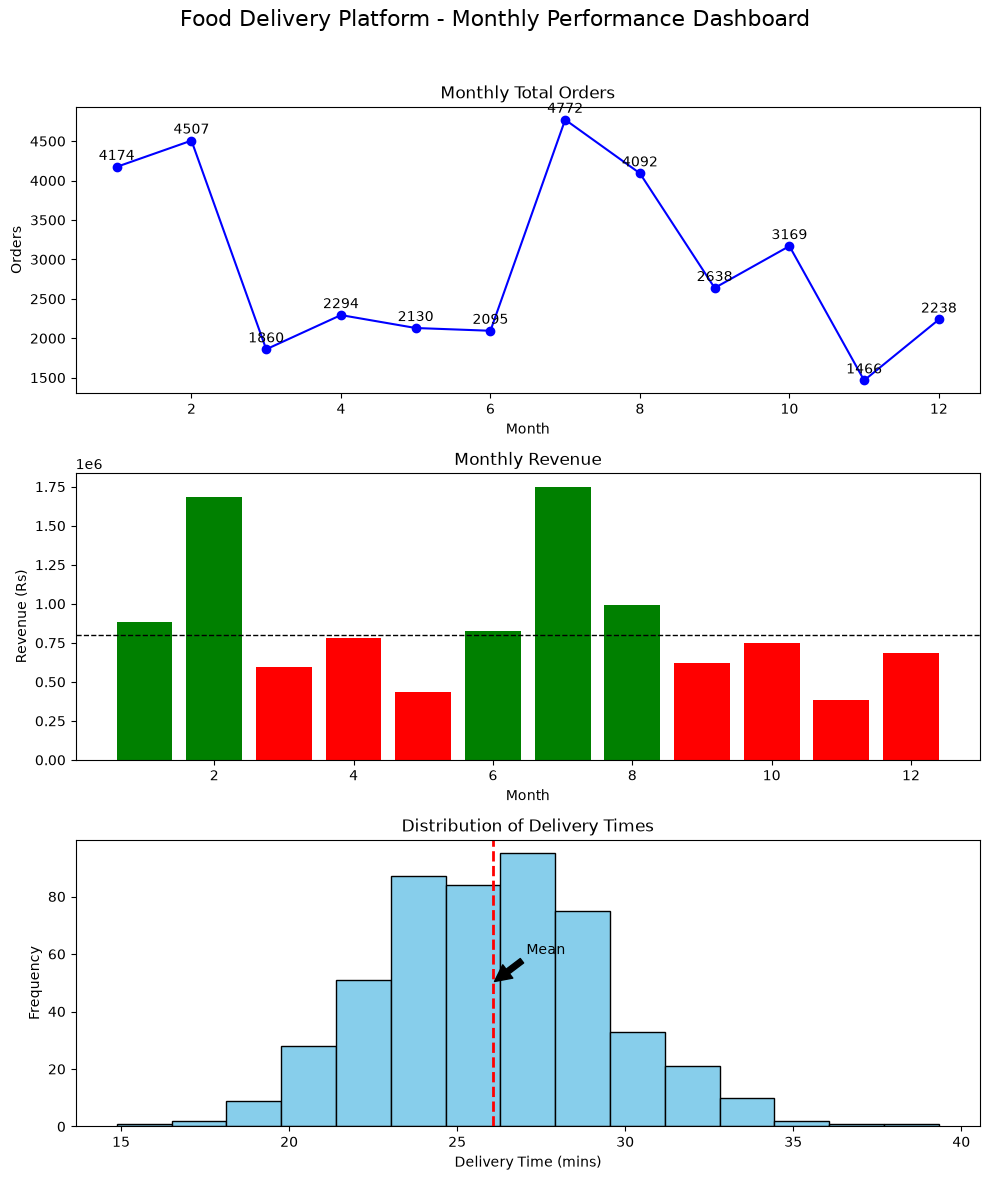

In [7]:
''' Subplot 1 — Line chart: Plot total orders per month with circular markers; annotate each data
point with its value displayed just above the marker. '''

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Line chart with circular markers
axes[0].plot(months, orders, marker='o', linestyle='-', color='blue')
axes[0].set_title("Monthly Total Orders")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Orders")

# Annotate each point with its value
for x, y in zip(months, orders):
    axes[0].annotate(str(y), xy=(x, y), xytext=(0, 5),
                     textcoords="offset points", ha='center')


''' Subplot 2 — Bar chart: Plot monthly revenue; colour each bar green if revenue exceeds Rs
8,00,000 and red otherwise, and draw a horizontal dashed line at the Rs 8,00,000 threshold. '''

colors = ['green' if val > 800000 else 'red' for val in revenue]
axes[1].bar(months, revenue, color=colors)
axes[1].axhline(800000, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Monthly Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue (Rs)")


''' Subplot 3 — Histogram: Plot 500 simulated delivery times (use the generated mean and std)
with 15 bins; add a vertical dashed line at the sample mean labelled 'Mean'. '''

# Simulate 500 delivery times using mean and std
simulated_times = np.random.normal(loc=np.mean(delivery_times),
                                   scale=np.std(delivery_times),
                                   size=500)

axes[2].hist(simulated_times, bins=15, color='skyblue', edgecolor='black')
axes[2].axvline(np.mean(simulated_times), color='red', linestyle='--', linewidth=2)
axes[2].annotate("Mean", xy=(np.mean(simulated_times), 50),
                 xytext=(np.mean(simulated_times)+1, 60),
                 arrowprops=dict(facecolor='black', shrink=0.05))
axes[2].set_title("Distribution of Delivery Times")
axes[2].set_xlabel("Delivery Time (mins)")
axes[2].set_ylabel("Frequency")

fig.suptitle("Food Delivery Platform - Monthly Performance Dashboard", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("food_delivery_dashboard.png", dpi=150)
plt.show()

#### Task 4: Full EDA Pipeline — Food Delivery Insights 
**Build an end-to-end exploratory analysis pipeline that generates, cleans, enriches, and
visualises a synthetic food delivery dataset using all four modules in sequence.**

In [8]:
''' Use NumPy (seed=7) to generate a 200-row dataset with columns: order_value (uniform Rs
100–Rs 800), distance_km (uniform 1–20), delivery_time_mins (normal ?=30, ?=8), rating
(uniform 1.0–5.0), and discount_pct (uniform 0–30); load it into a Pandas DataFrame. '''

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fixed seed for reproducibility
np.random.seed(7)

# Generate 200 rows of synthetic data
data = {
    "order_value": np.random.uniform(100, 800, 200),
    "distance_km": np.random.uniform(1, 20, 200),
    "delivery_time_mins": np.random.normal(loc=30, scale=8, size=200),
    "rating": np.random.uniform(1.0, 5.0, 200),
    "discount_pct": np.random.uniform(0, 30, 200)
}

df = pd.DataFrame(data)
df.head()

,order_value,distance_km,delivery_time_mins,rating,discount_pct
0,153.415803,15.287118,29.436359,1.610398,17.079069
1,645.943155,2.171641,41.143419,1.247733,4.256927
2,406.886462,15.151650,20.002291,3.285994,18.347489
3,606.425624,18.979243,18.019293,1.749068,29.233717
4,784.592658,12.467631,24.767687,3.171931,8.202608


In [9]:
''' Artificially introduce 5% null values into the delivery_time_mins and rating columns using
np.random.choice(); then fill all nulls with the respective column medians. '''

# Randomly select 5% indices
null_indices = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
df.loc[null_indices, "delivery_time_mins"] = np.nan

null_indices = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
df.loc[null_indices, "rating"] = np.nan

# Fill nulls with column medians
df["delivery_time_mins"] = df["delivery_time_mins"].fillna(df["delivery_time_mins"].median())
df["rating"] = df["rating"].fillna(df["rating"].median())

In [10]:
''' Add a derived column: delivery_speed_kmph = distance_km / (delivery_time_mins / 60);
classify each row into a speed_band category ('Fast', 'Normal', 'Slow') using pd.qcut() on
delivery_speed_kmph with 3 equal-frequency bins. '''


df["delivery_speed_kmph"] = df["distance_km"] / (df["delivery_time_mins"] / 60)

# Classify into speed bands using qcut (3 equal-frequency bins)
df["speed_band"] = pd.qcut(df["delivery_speed_kmph"], q=3, labels=["Slow", "Normal", "Fast"])


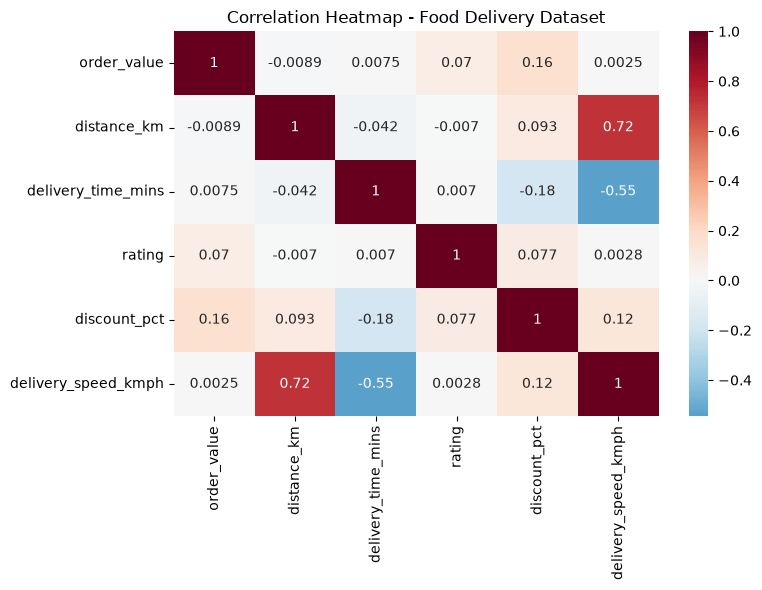

In [11]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute Pearson correlation
corr = numeric_df.corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap - Food Delivery Dataset")
plt.tight_layout()
plt.show()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.close()

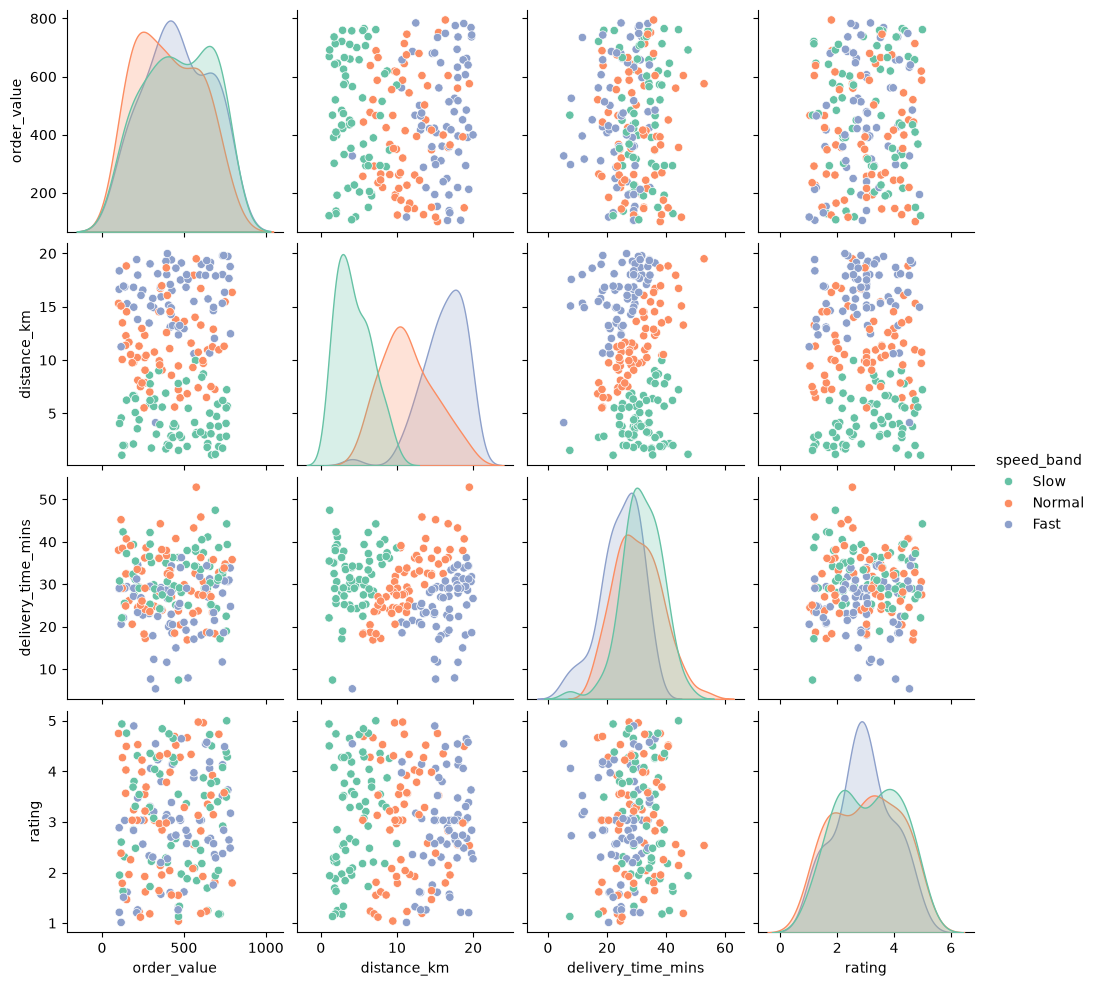

In [12]:
''' Produce a Seaborn pairplot of order_value, distance_km, delivery_time_mins, and rating,
coloured by speed_band; save as pairplot.png. Both charts must be saved at DPI >= 150 using
plt.savefig(). '''

sns.pairplot(df[["order_value", "distance_km", "delivery_time_mins", "rating", "speed_band"]],
             hue="speed_band", palette="Set2")
plt.savefig("pairplot.png", dpi=150)
plt.show()
plt.close()